# Campus-Wide Sustainability Tracker

This notebook implements a basic framework for tracking campus-wide sustainability metrics. It includes:
-   Generation of synthetic data representing energy consumption.
-   Data aggregation.
-   Application of basic predictive models (linear regression and exponential smoothing).
-   Calculation of a key performance indicator (carbon savings).
-   Basic visualizations to understand trends and model performance.

## 1. Setup and Library Imports

In [1]:
# Install necessary libraries
!pip install pandas numpy scikit-learn statsmodels matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import mean_squared_error

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Synthetic Data Generation

Since no specific data was provided, we'll generate synthetic energy consumption data for different campus buildings over a period.

In [3]:
np.random.seed(42)

# Generate dates for one year
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Campus buildings
buildings = ['Library', 'Admin Block', 'Science Lab', 'Student Dorms', 'Cafeteria']

data = []
for date in dates:
    for building in buildings:
        # Simulate energy consumption with some trend and seasonality
        base_consumption = 50 + np.random.rand() * 20 # kWh
        # Add a slight increasing trend over the year
        trend_factor = (date - dates[0]).days / 365 * 10
        # Add seasonality (higher consumption in winter, lower in summer)
        month = date.month
        seasonal_factor = 10 * np.cos((month - 1) / 12 * 2 * np.pi) # Simple sine wave for seasonality

        consumption = base_consumption + trend_factor + seasonal_factor + np.random.normal(0, 5)
        # Ensure consumption is not negative
        consumption = max(0, consumption)
        data.append({'Date': date, 'Building': building, 'Energy_Consumption_kWh': consumption})

df = pd.DataFrame(data)

print("Synthetic data generated.")
display(df.head())

Synthetic data generated.


,Date,Building,Energy_Consumption_kWh
0,2023-01-01,Library,61.931402
1,2023-01-01,Admin Block,64.714401
2,2023-01-01,Science Lab,62.556879
3,2023-01-01,Student Dorms,79.214028
4,2023-01-01,Cafeteria,57.507299


## 3. Data Aggregation

Aggregate the data to get total daily energy consumption for the entire campus and also by building.

In [4]:
# Aggregate total daily consumption for the campus
daily_campus_consumption = df.groupby('Date')['Energy_Consumption_kWh'].sum().reset_index()
daily_campus_consumption.rename(columns={'Energy_Consumption_kWh': 'Total_Campus_Consumption_kWh'}, inplace=True)

# Aggregate daily consumption by building
daily_building_consumption = df.groupby(['Date', 'Building'])['Energy_Consumption_kWh'].sum().reset_index()

print("Data aggregated.")
display(daily_campus_consumption.head())
display(daily_building_consumption.head())

Data aggregated.


,Date,Total_Campus_Consumption_kWh
0,2023-01-01,325.924009
1,2023-01-02,318.489789
2,2023-01-03,331.113743
3,2023-01-04,339.510970
4,2023-01-05,370.394617


,Date,Building,Energy_Consumption_kWh
0,2023-01-01,Admin Block,64.714401
1,2023-01-01,Cafeteria,57.507299
2,2023-01-01,Library,61.931402
3,2023-01-01,Science Lab,62.556879
4,2023-01-01,Student Dorms,79.214028


## 4. Ensemble Basic Models (Regression + Smoothing)

We'll apply a simple linear regression model and an Exponential Smoothing model to predict future energy consumption. For demonstration, we'll use the total campus consumption.

In [14]:
# Prepare data for modeling
daily_campus_consumption['Day_Number'] = (daily_campus_consumption['Date'] - daily_campus_consumption['Date'].min()).dt.days
X = daily_campus_consumption[['Day_Number']]
y = daily_campus_consumption['Total_Campus_Consumption_kWh']

# Split data into training and testing (e.g., 80% train, 20% test)
train_size = int(len(daily_campus_consumption) * 0.8) # Corrected: use len(daily_campus_consumption)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training data size: {len(X_train)}")
print(f"Testing data size: {len(X_test)}")

Training data size: 292
Testing data size: 73


### 4.1 Linear Regression Model

In [15]:
# Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
print(f"Linear Regression RMSE: {rmse_linear:.2f}")

Linear Regression RMSE: 98.95


### 4.2 Exponential Smoothing Model

In [16]:
# Exponential Smoothing Model
# Using Holt's linear trend method for a simple demonstration
fit_es = Holt(np.asarray(y_train), initialization_method="estimated").fit()
y_pred_es = fit_es.forecast(len(y_test))

rmse_es = np.sqrt(mean_squared_error(y_test, y_pred_es))
print(f"Exponential Smoothing RMSE: {rmse_es:.2f}")

Exponential Smoothing RMSE: 31.84


### 4.3 Ensemble (Simple Averaging for demonstration)

For simplicity, we'll demonstrate a basic ensemble by averaging the predictions from the two models. More sophisticated ensemble techniques (e.g., stacking, blending) could be used.

In [17]:
# Simple ensemble by averaging predictions
y_pred_ensemble = (y_pred_linear + y_pred_es) / 2

rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
print(f"Ensemble Model (Averaging) RMSE: {rmse_ensemble:.2f}")

Ensemble Model (Averaging) RMSE: 40.41


## 5. KPI Calculation: Carbon Savings

To calculate carbon savings, we need a baseline or a target. We'll define a hypothetical target consumption and calculate savings based on actual versus target consumption. We'll assume a carbon emission factor for electricity.

In [18]:
# Define a carbon emission factor (e.g., kg CO2 per kWh)
# This value can vary significantly based on electricity source (grid mix)
carbon_emission_factor_kg_per_kWh = 0.4 # Example value for kg CO2 per kWh

# Define a hypothetical baseline/target consumption.
# Let's say, we aimed to keep daily campus consumption below a certain threshold
# For this demo, let's set a target of 85% of the average of the first month's consumption as the baseline.

initial_average_consumption = daily_campus_consumption['Total_Campus_Consumption_kWh'].iloc[:30].mean()
target_daily_consumption = initial_average_consumption * 0.9 # Aim for 10% reduction from initial average

# Calculate actual emissions
daily_campus_consumption['Actual_Emissions_kgCO2'] = daily_campus_consumption['Total_Campus_Consumption_kWh'] * carbon_emission_factor_kg_per_kWh

# Calculate target emissions based on `target_daily_consumption`
daily_campus_consumption['Target_Emissions_kgCO2'] = target_daily_consumption * carbon_emission_factor_kg_per_kWh

# Calculate carbon savings (if actual is below target)
daily_campus_consumption['Carbon_Savings_kgCO2'] = np.maximum(0, daily_campus_consumption['Target_Emissions_kgCO2'] - daily_campus_consumption['Actual_Emissions_kgCO2'])

# Calculate cumulative carbon savings
daily_campus_consumption['Cumulative_Carbon_Savings_kgCO2'] = daily_campus_consumption['Carbon_Savings_kgCO2'].cumsum()

print("Carbon savings calculated.")
display(daily_campus_consumption.head())

Carbon savings calculated.


,Date,Total_Campus_Consumption_kWh,Day_Number,Actual_Emissions_kgCO2,Target_Emissions_kgCO2,Carbon_Savings_kgCO2,Cumulative_Carbon_Savings_kgCO2
0,2023-01-01,325.924009,0,130.369604,125.687245,0.0,0.0
1,2023-01-02,318.489789,1,127.395915,125.687245,0.0,0.0
2,2023-01-03,331.113743,2,132.445497,125.687245,0.0,0.0
3,2023-01-04,339.510970,3,135.804388,125.687245,0.0,0.0
4,2023-01-05,370.394617,4,148.157847,125.687245,0.0,0.0


## 6. Basic Visualizations (towards a Dashboard)

These visualizations can form components of a comprehensive dashboard, showing overall trends, model performance, and KPI progression.

### 6.1 Total Campus Energy Consumption Over Time

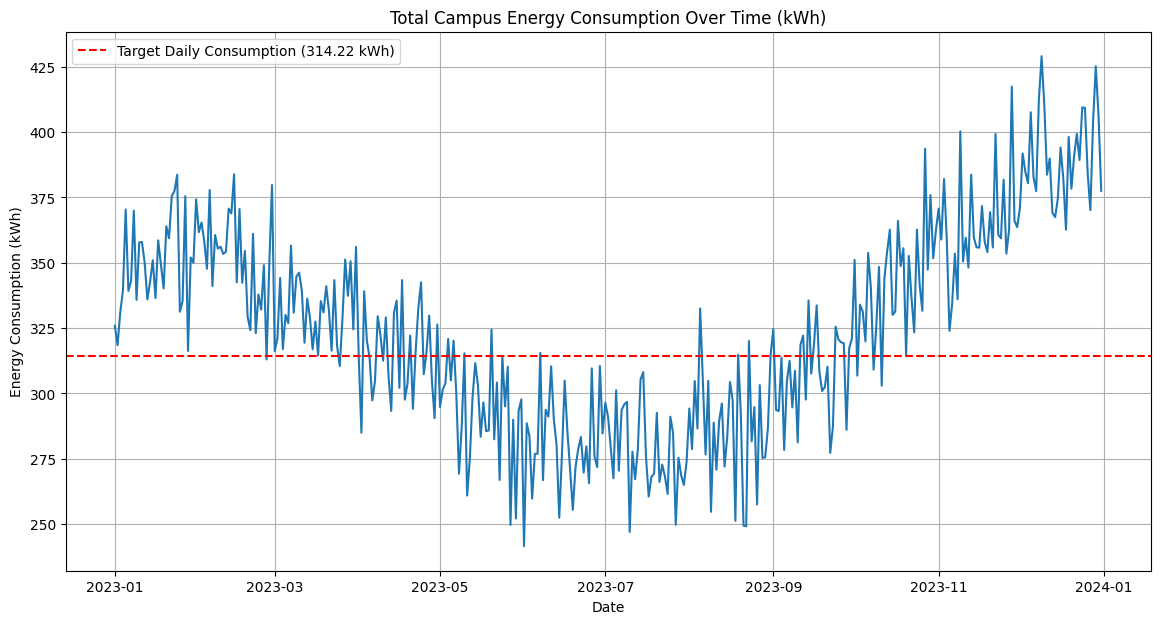

In [19]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Total_Campus_Consumption_kWh', data=daily_campus_consumption)
plt.axhline(y=target_daily_consumption, color='r', linestyle='--', label=f'Target Daily Consumption ({target_daily_consumption:.2f} kWh)')
plt.title('Total Campus Energy Consumption Over Time (kWh)')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

### 6.2 Model Predictions vs. Actuals

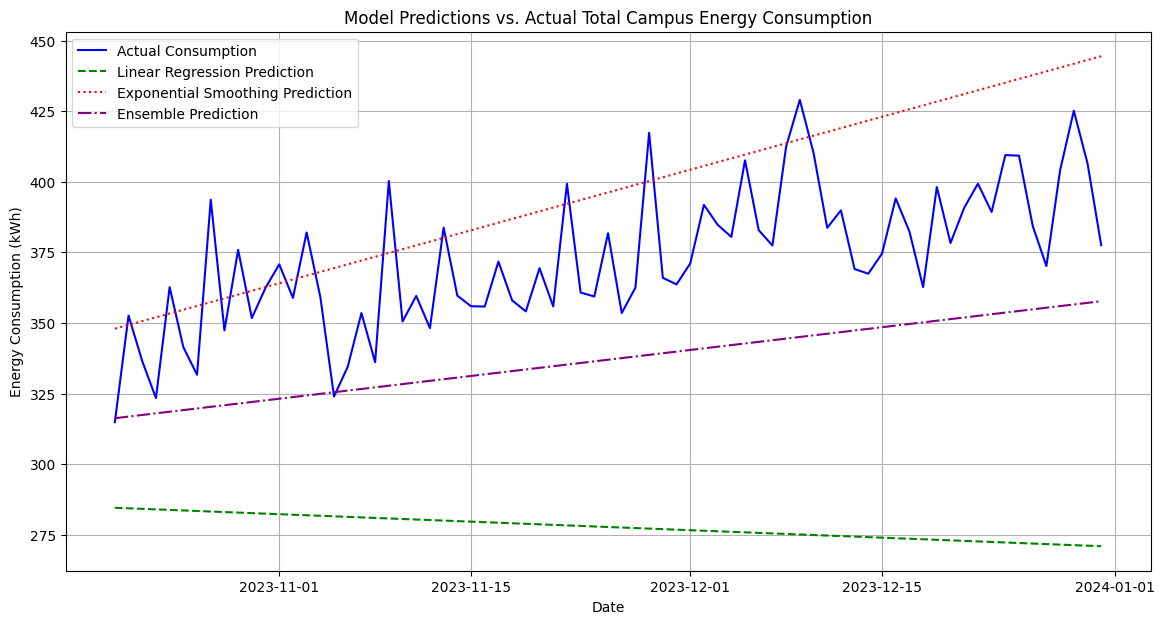

In [20]:
plt.figure(figsize=(14, 7))
plt.plot(daily_campus_consumption['Date'][train_size:], y_test, label='Actual Consumption', color='blue')
plt.plot(daily_campus_consumption['Date'][train_size:], y_pred_linear, label='Linear Regression Prediction', color='green', linestyle='--')
plt.plot(daily_campus_consumption['Date'][train_size:], y_pred_es, label='Exponential Smoothing Prediction', color='red', linestyle=':')
plt.plot(daily_campus_consumption['Date'][train_size:], y_pred_ensemble, label='Ensemble Prediction', color='purple', linestyle='-.')

plt.title('Model Predictions vs. Actual Total Campus Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

### 6.3 Carbon Savings Trend

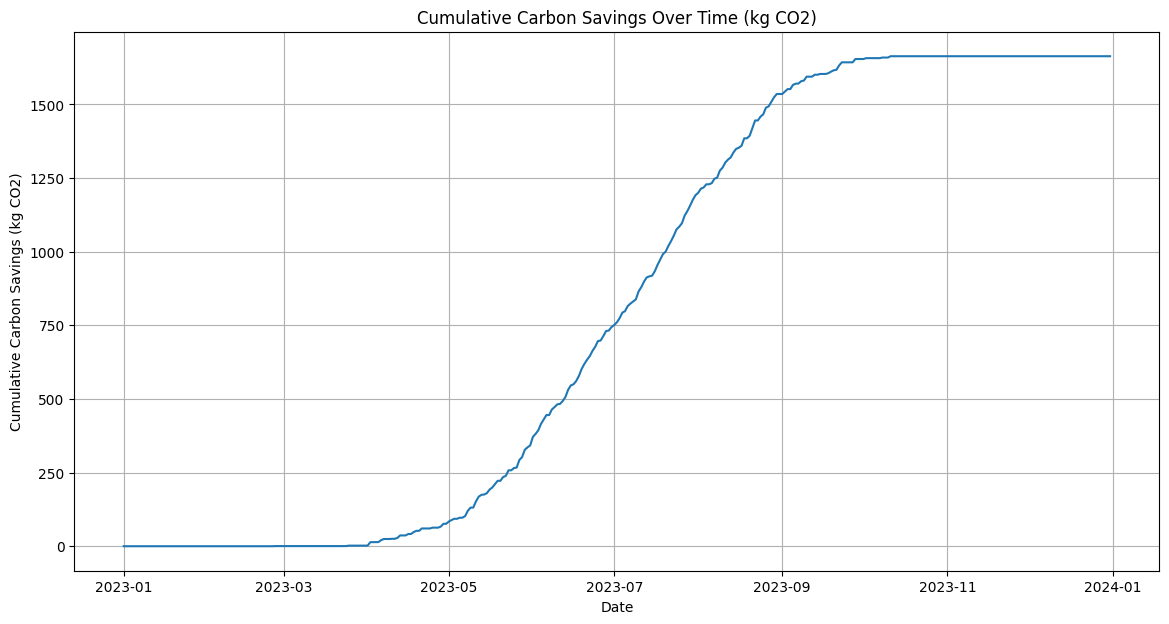

In [21]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Cumulative_Carbon_Savings_kgCO2', data=daily_campus_consumption)
plt.title('Cumulative Carbon Savings Over Time (kg CO2)')
plt.xlabel('Date')
plt.ylabel('Cumulative Carbon Savings (kg CO2)')
plt.grid(True)
plt.show()

### 6.4 Drill-down View: Energy Consumption by Building

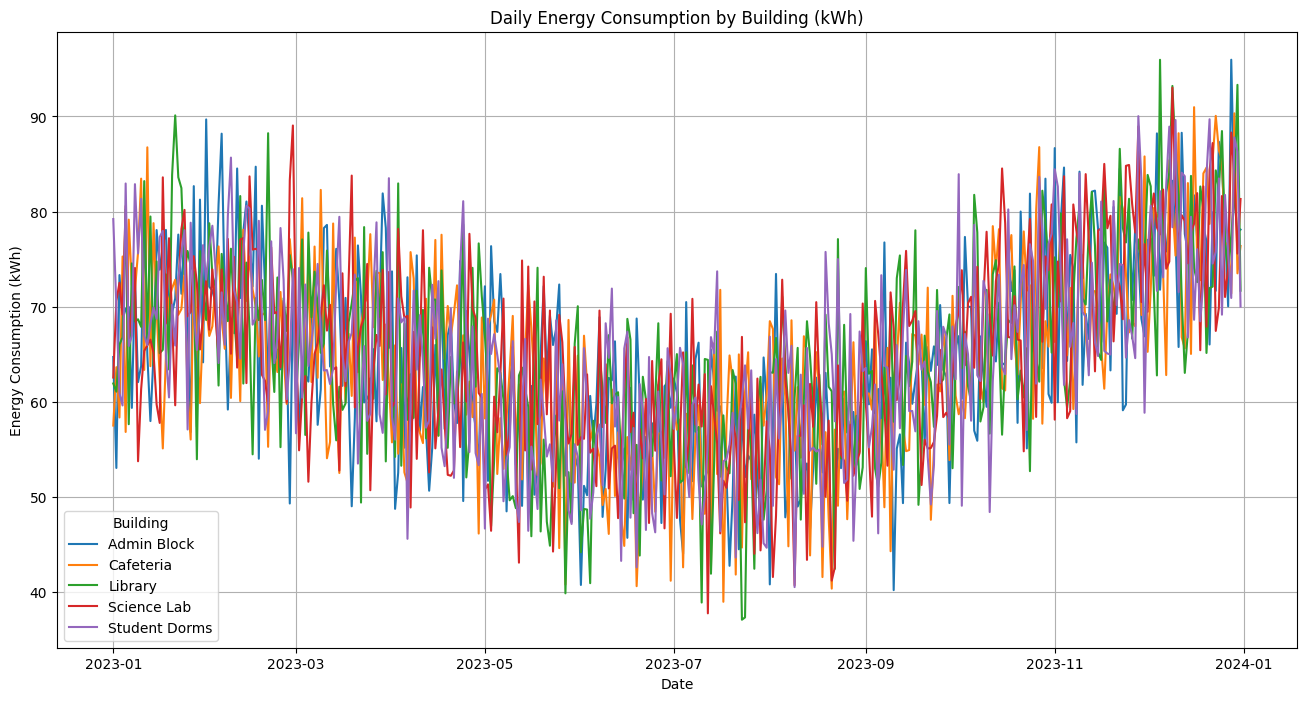

In [22]:
plt.figure(figsize=(16, 8))
sns.lineplot(x='Date', y='Energy_Consumption_kWh', hue='Building', data=daily_building_consumption)
plt.title('Daily Energy Consumption by Building (kWh)')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend(title='Building')
plt.grid(True)
plt.show()